In [2]:
import torch
import kagglehub

In [5]:
!pip install kagglehub kaggle

In [3]:
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [4]:
from google.colab import files
files.upload()  # Upload kaggle.json file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tuladhar07","key":"7a497c52203d8bec2cb371f1a65d1e15"}'}

In [5]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset


Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
 95% 733M/775M [00:08<00:00, 52.6MB/s]
100% 775M/775M [00:08<00:00, 90.5MB/s]


In [7]:
import os
import zipfile
!apt-get install tree
from tqdm import tqdm

zip_path = '/content/dog-and-cat-classification-dataset.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print(f"Unzipping {zip_path}...")
    zip_ref.extractall()
    print("Unzipping complete!")

# Let's see the directory structure
# The `tree` command gives a nice visual overview
!tree -d PetImages/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (68.3 kB/s)
Selecting previously unselected package tree.
(Reading database ... 126111 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
Unzipping /content/dog-and-cat-classification-dataset.zip...
Unzipping complete!
PetImages/
├── Cat
└── Dog

2 directories


In [8]:
#splitting the dataset
import os
import shutil
import random
from PIL import Image
from tqdm import tqdm

def clean_and_split_data(source_dir='PetImages', target_dir='data', split_ratio=0.8):
    # --- 1. Data Cleaning ---
    print("--- Starting Data Cleaning ---")
    num_corrupt = 0
    for class_name in ['Cat', 'Dog']:
        class_dir = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"Directory not found: {class_dir}")
            continue
        for filename in tqdm(os.listdir(class_dir), desc=f"Cleaning {class_name} images"):
            filepath = os.path.join(class_dir, filename)
            # Check for zero-byte files
            if os.path.getsize(filepath) == 0:
                print(f"Removing zero-byte file: {filepath}")
                os.remove(filepath)
                num_corrupt += 1
                continue
            # Check for corrupt image headers
            try:
                with Image.open(filepath) as img:
                    img.verify()
            except (IOError, SyntaxError):
                print(f"Removing corrupt image: {filepath}")
                os.remove(filepath)
                num_corrupt += 1
    print(f"--- Data Cleaning Complete. Removed {num_corrupt} files. ---\n")

    # --- 2. Data Splitting ---
    print("--- Starting Data Splitting ---")
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir) # Start with a fresh directory

    # Create destination directories
    train_cat_dir = os.path.join(target_dir, 'train', 'cats')
    train_dog_dir = os.path.join(target_dir, 'train', 'dogs')
    val_cat_dir = os.path.join(target_dir, 'val', 'cats')
    val_dog_dir = os.path.join(target_dir, 'val', 'dogs')
    os.makedirs(train_cat_dir, exist_ok=True)
    os.makedirs(train_dog_dir, exist_ok=True)
    os.makedirs(val_cat_dir, exist_ok=True)
    os.makedirs(val_dog_dir, exist_ok=True)

    # Split and copy files for each class
    for class_name, train_dir, val_dir in [('Cat', train_cat_dir, val_cat_dir), ('Dog', train_dog_dir, val_dog_dir)]:
        source_class_dir = os.path.join(source_dir, class_name)
        files = os.listdir(source_class_dir)
        random.shuffle(files)

        split_point = int(len(files) * split_ratio)
        train_files = files[:split_point]
        val_files = files[split_point:]

        for f in tqdm(train_files, desc=f"Copying {class_name} train files"):
            shutil.copy(os.path.join(source_class_dir, f), train_dir)
        for f in tqdm(val_files, desc=f"Copying {class_name} val files"):
            shutil.copy(os.path.join(source_class_dir, f), val_dir)

    print("--- Data Splitting Complete ---")
    print(f"Training cats: {len(os.listdir(train_cat_dir))}, Training dogs: {len(os.listdir(train_dog_dir))}")
    print(f"Validation cats: {len(os.listdir(val_cat_dir))}, Validation dogs: {len(os.listdir(val_dog_dir))}")

# Run the cleaning and splitting process
clean_and_split_data()

--- Starting Data Cleaning ---


Cleaning Dog images:  31%|███       | 3827/12499 [00:00<00:00, 12720.72it/s]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Cleaning Dog images: 100%|██████████| 12499/12499 [00:01<00:00, 12138.09it/s]


--- Data Cleaning Complete. Removed 0 files. ---

--- Starting Data Splitting ---


Copying Dog val files: 100%|██████████| 2500/2500 [00:01<00:00, 2087.07it/s]

--- Data Splitting Complete ---
Training cats: 9999, Training dogs: 9999
Validation cats: 2500, Validation dogs: 2500


In [9]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 0.0001

# ImageNet statistics for normalization
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Define transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ]),
}

# Use our newly created 'data' directory
data_dir = 'data'
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(data_dir, 'val'), data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Class names: {class_names}")
print(f"Training set size: {dataset_sizes['train']}")

Class names: ['cats', 'dogs']
Training set size: 19998


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
class AlexNet(nn.Module):
    def __init__(self, num_classes: int = 2) -> None:
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True), nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5), nn.Linear(256 * 6 * 6, 4096), nn.ReLU(inplace=True),
            nn.Dropout(p=0.5), nn.Linear(4096, 4096), nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNet(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)

Using device: cuda
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features

In [19]:
def train_model(model, criterion, optimizer, num_epochs=10):
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}\n' + '-'*10)
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects = 0.0, 0
            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), 'alexnet_best_model.pth')
                print(f'New best model saved with accuracy: {best_acc:.4f}')
    print(f'\nBest val Acc: {best_acc:4f}')
    model.load_state_dict(torch.load('alexnet_best_model.pth'))
    return model, history

trained_model, history = train_model(model, criterion, optimizer, num_epochs=EPOCHS)

Epoch 1/15
----------


train:  81%|████████  | 127/157 [00:56<00:11,  2.72it/s]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
train: 100%|██████████| 157/157 [01:09<00:00,  2.25it/s]


train Loss: 0.6661 Acc: 0.5899


val: 100%|██████████| 40/40 [00:20<00:00,  1.97it/s]


val Loss: 0.6316 Acc: 0.6320
New best model saved with accuracy: 0.6320
Epoch 2/15
----------


...

val Loss: 0.2906 Acc: 0.8814
Epoch 15/15
----------


train:  88%|████████▊ | 138/157 [01:01<00:07,  2.50it/s]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
train: 100%|██████████| 157/157 [01:08<00:00,  2.30it/s]


train Loss: 0.2880 Acc: 0.8682


val: 100%|██████████| 40/40 [00:19<00:00,  2.04it/s]


val Loss: 0.2313 Acc: 0.8974

Best val Acc: 0.906200


Evaluating: 100%|██████████| 40/40 [00:19<00:00,  2.10it/s]



Classification Report:
              precision    recall  f1-score   support

        cats       0.92      0.89      0.90      2500
        dogs       0.89      0.92      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



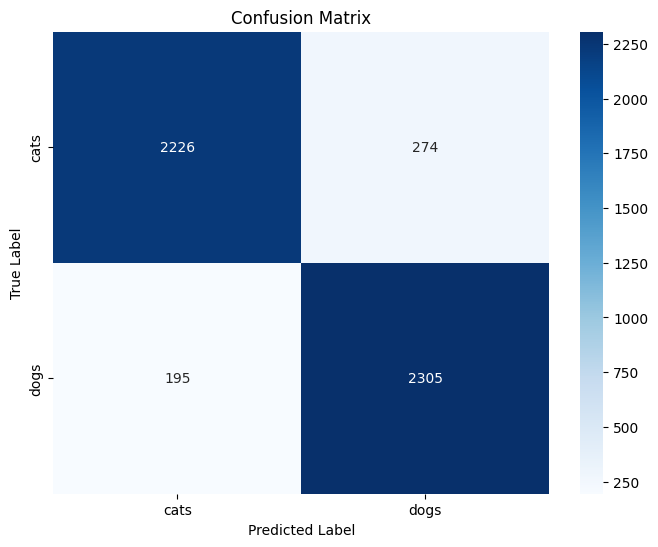

In [20]:
def evaluate_model(model, dataloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return y_true, y_pred

y_true, y_pred = evaluate_model(trained_model, dataloaders['val'])

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

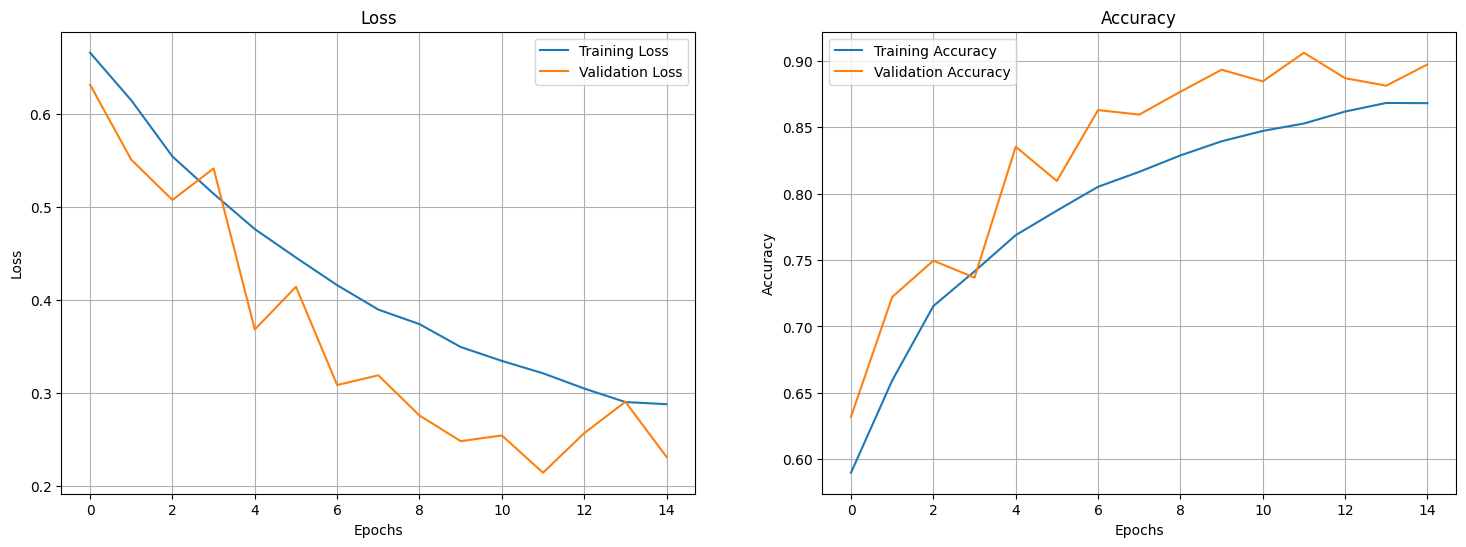

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.plot(history['train_loss'], label='Training Loss')
ax1.plot(history['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss'); ax1.set_title('Loss')
ax1.legend(); ax1.grid(True)
ax2.plot(history['train_acc'], label='Training Accuracy')
ax2.plot(history['val_acc'], label='Validation Accuracy')
ax2.set_xlabel('Epochs'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy')
ax2.legend(); ax2.grid(True)
plt.show()

In [23]:
#modified Model
LEARNING_RATE =1e-4   # or any value you're using
WEIGHT_DECAY = 1e-5
import torch
import torch.nn as nn
import torch.optim as optim
# from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim.lr_scheduler import CosineAnnealingLR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class AlexNetDeeper(nn.Module):
    def __init__(self, num_classes: int = 2) -> None:
        super(AlexNetDeeper, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

if dataloaders:  # ensure dataloaders exists
    model = AlexNetDeeper(num_classes=len(class_names)).to(device)

    # Weight init function
    def initialize_weights(m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0, 0.01)
            nn.init.constant_(m.bias, 0)

    model.apply(initialize_weights)

    criterion = nn.CrossEntropyLoss()

    # Optimizer — try SGD + momentum or Adam with lower LR
    optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=WEIGHT_DECAY)
    # optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)

    # Scheduler: Cosine Annealing
    scheduler = CosineAnnealingLR(optimizer, T_max=10)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel: AlexNetDeeper created with {total_params:,} trainable parameters.")
    print(model)
else:
    model = None
    print("\nModel not created as data is not ready.")


Model: AlexNetDeeper created with 60,948,802 trainable parameters.
AlexNetDeeper(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=Tru

In [24]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10, save_path='best_model.pth'):
     if not model or not dataloaders:
        print("Model or DataLoaders not available. Skipping training.")
        return None, None
     print("\n--- Starting Training ---")
     start_time = time.time()
     best_acc = 0.0
     history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

     for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}\n' + '-'*10)
        epoch_val_loss = 0.0 # To pass to scheduler

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects = 0.0, 0
            # Added a check for corrupted files during batch loading
            for i, (inputs, labels) in enumerate(tqdm(dataloaders[phase], desc=phase)):
                 try:
                    inputs, labels = inputs.to(device), labels.to(device)
                 except Exception as e:
                     print(f"\nSkipping batch {i} due to loading error: {e}")
                     continue # Skip this batch if an image is still bad

                 optimizer.zero_grad()
                 with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                 running_loss += loss.item() * inputs.size(0)
                 running_corrects += torch.sum(preds == labels.data)

            # Handle case where dataset_size might be 0 if all batches fail
            if dataset_sizes[phase] > 0 :
               epoch_loss = running_loss / dataset_sizes[phase]
               epoch_acc = running_corrects.double() / dataset_sizes[phase]
            else:
                epoch_loss = float('inf')
                epoch_acc = 0.0


            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                epoch_val_loss = epoch_loss # store for scheduler
                if epoch_acc > best_acc:
                   best_acc = epoch_acc
                   torch.save(model.state_dict(), save_path)
                   print(f'New best model saved to {save_path} with accuracy: {best_acc:.4f}')

        # --- Step the scheduler based on validation loss ---
        scheduler.step(epoch_val_loss)

     time_elapsed = time.time() - start_time
     print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
     print(f'Best val Acc: {best_acc:4f}')
     # Load best model weights before returning
     if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path))
     return model, history

# Train with the new model and save path
trained_model, history = train_model(
    model, criterion, optimizer, scheduler,
    num_epochs=EPOCHS
    )


--- Starting Training ---

Epoch 1/15
----------


train:  94%|█████████▍| 148/157 [01:09<00:03,  2.68it/s]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
train: 100%|██████████| 157/157 [01:13<00:00,  2.14it/s]


train Loss: 0.7135 Acc: 0.5559


val: 100%|██████████| 40/40 [00:19<00:00,  2.05it/s]


val Loss: 0.6370 Acc: 0.6338


...

val Loss: 0.4690 Acc: 0.7652

Epoch 15/15
----------


train:  52%|█████▏    | 82/157 [00:37<00:30,  2.50it/s]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
train: 100%|██████████| 157/157 [01:11<00:00,  2.20it/s]


train Loss: 0.4256 Acc: 0.7987


val: 100%|██████████| 40/40 [00:18<00:00,  2.14it/s]


val Loss: 0.7444 Acc: 0.6814

Training complete in 22m 29s
Best val Acc: 0.841400


Evaluating: 100%|██████████| 40/40 [00:20<00:00,  1.97it/s]



Classification Report:
              precision    recall  f1-score   support

        cats       0.92      0.75      0.83      2500
        dogs       0.79      0.93      0.85      2500

    accuracy                           0.84      5000
   macro avg       0.85      0.84      0.84      5000
weighted avg       0.85      0.84      0.84      5000



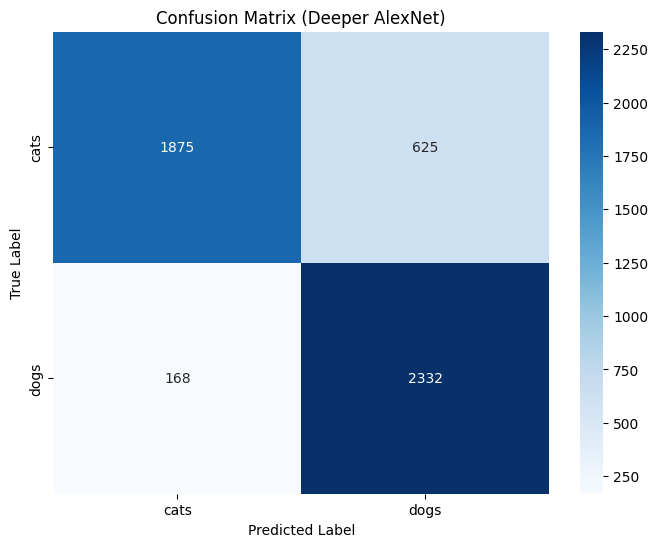

In [25]:
def evaluate_model(model, dataloader):
     if not model or not dataloader:
        print("Model or DataLoader not available. Skipping evaluation.")
        return [], []
     model.eval()
     y_true, y_pred = [], []
     with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
             try:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
             except Exception as e:
                print(f"\nSkipping evaluation batch due to error: {e}")
                continue
     return y_true, y_pred

if trained_model and dataloaders:
  y_true, y_pred = evaluate_model(trained_model, dataloaders['val'])

  if y_true and y_pred:
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Deeper AlexNet)')
    plt.show()
  else:
      print("Evaluation failed or returned no data.")
else:
     print("Cannot evaluate: model was not trained or data not loaded.")



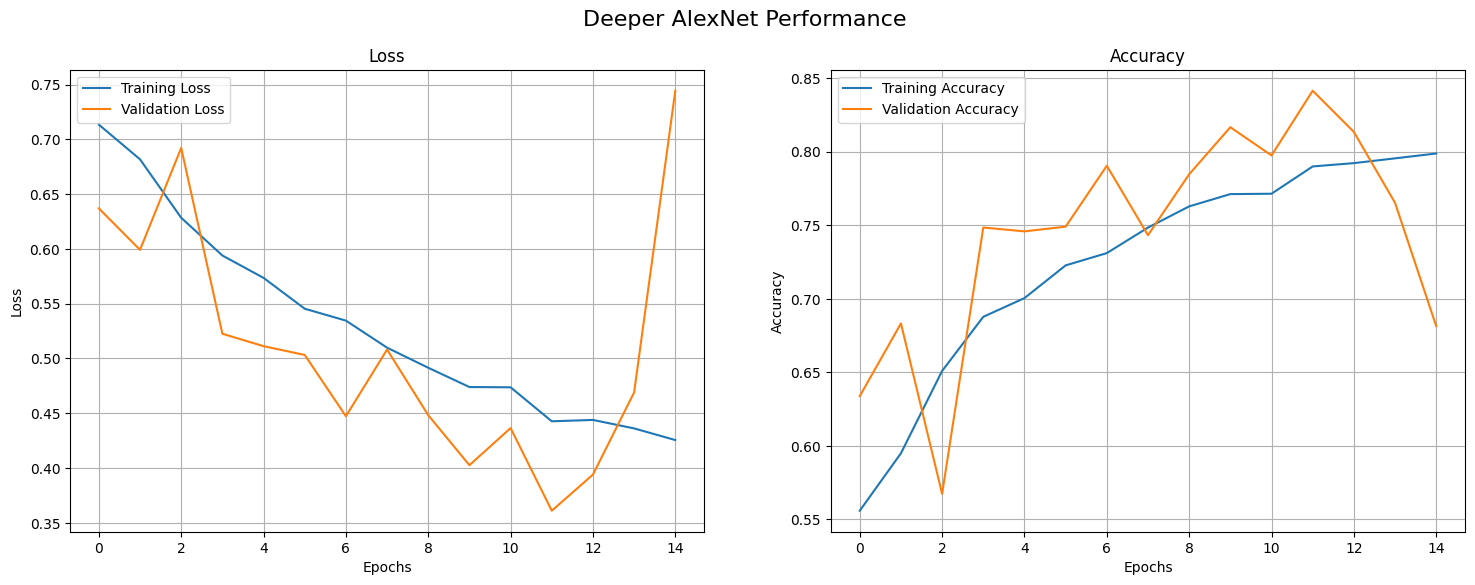

In [26]:
if history:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
  fig.suptitle('Deeper AlexNet Performance', fontsize=16)
  ax1.plot(history['train_loss'], label='Training Loss')
  ax1.plot(history['val_loss'], label='Validation Loss')
  ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss'); ax1.set_title('Loss')
  ax1.legend(); ax1.grid(True)
  ax2.plot(history['train_acc'], label='Training Accuracy')
  ax2.plot(history['val_acc'], label='Validation Accuracy')
  ax2.set_xlabel('Epochs'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy')
  ax2.legend(); ax2.grid(True)
  plt.show()
else:
   print("Cannot plot history: training did not run.")